# Problem - 1: Perform a classification task with knn from scratch.

1. Load the dataset

In [2]:
import pandas as pd
import numpy as np
# Loading the dataset into a pandas DataFrame
diabetes_df = pd.read_csv('/content/drive/MyDrive/Datasets/Week2/diabetes_.csv')

# Displaying the first few rows
display(diabetes_df.head())

# Checking the data types involved in the data
print(diabetes_df.info())

# Checking for missing values
  #Replacing the 0 values with NaN

# Since these columns physiologically cannot have a 0 value we treat them as NaN
cols_with_invalid_zeros = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

diabetes_df[cols_with_invalid_zeros] = diabetes_df[cols_with_invalid_zeros].replace(0, np.nan)

print(diabetes_df.isnull().sum())

# Summary statistics

diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age        

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


2. Handle missing Data:
• Handle any missing values appropriately, either by dropping or imputing them based on the data.

In [3]:
missing_info = diabetes_df.isnull().sum()/len(diabetes_df) *100

for column in diabetes_df.columns:
  if missing_info[column] > 10 : #If more than 10% missing
    diabetes_df[column].fillna(diabetes_df[column].mean(), inplace= True)
  else: #If less than 10% missing
    diabetes_df.dropna(subset=[column], inplace = True)

# Display cleaned data
print("Data after processing:\n", diabetes_df.head())
print("\nMissing values after processing:\n", diabetes_df.isnull().sum())

Data after processing:
    Pregnancies  Glucose  BloodPressure  SkinThickness     Insulin   BMI  \
0            6    148.0           72.0      35.000000  155.885496  33.6   
1            1     85.0           66.0      29.000000  155.885496  26.6   
2            8    183.0           64.0      29.159176  155.885496  23.3   
3            1     89.0           66.0      23.000000   94.000000  28.1   
4            0    137.0           40.0      35.000000  168.000000  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Missing values after processing:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age             

/tmp/ipython-input-933893978.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  diabetes_df[column].fillna(diabetes_df[column].mean(), inplace= True)


3. Feature Engineering:
• Separate the feature matrix (X) and target variable (y).
• Perform a train - test split from scratch using a 70% − 30% ratio.

In [4]:
#Seperate the features(X) and target(y)
X = diabetes_df.drop(columns=['Outcome']).values #converitng the features into a numpy array
y = diabetes_df['Outcome'].values  # Converting the target to NumPy array

# function for train-test split from scratch

def train_test_split_scratch(X, y, test_size=0.3, random_seed=42):
  """
  Splits dataset into train and test sets.
  Arguments:
  X : np.ndarray
      Feature matrix.
  y : np.ndarray
      Target array.
  test_size : float
      Proportion of the dataset to include in the test split (0 < test_size < 1).
  random_seed : int
      Seed for reproducibility.
  Returns:
      X_train, X_test, y_train, y_test : np.ndarray
      Training and testing splits of features and target.
  """
  np.random.seed(random_seed)
  indices = np.arange(X.shape[0])
  np.random.shuffle(indices) # Shuffle the indices
  test_split_size = int(len(X) * test_size)
  test_indices = indices[:test_split_size]
  train_indices = indices[test_split_size:]
  X_train, X_test = X[train_indices], X[test_indices]
  y_train, y_test = y[train_indices], y[test_indices]
  return X_train, X_test, y_train, y_test
# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split_scratch(X, y, test_size=0.3)
# Output shapes to verify
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)




Shape of X_train: (507, 8)
Shape of X_test: (217, 8)
Shape of y_train: (507,)
Shape of y_test: (217,)


4. Implement KNN:
• Build the KNN algorithm from scratch (no libraries like sickit-learn for KNN).
• Compute distances using Euclidean distance.
• Write functions for:
– Predicting the class for a single query.
– Predicting classes for all test samples.
• Evaluate the performance using accuracy.

In [5]:
# function to calculate the euclidean distance

def euclidean_distance(point1, point2):
  """
  Calculate the Euclidean distance between two points in n-dimensional space.
  Arguments:
  point1 : np.ndarray
    The first point as a numpy array.
  point2 : np.ndarray
    The second point as a numpy array.
  Returns:
  float
    The Euclidean distance between the two points.
  Raises:
  ValueError: If the input points do not have the same dimensionality.
  """
  # Check if the points are of the same dimension
  if point1.shape != point2.shape:
    raise ValueError("Points must have the same dimensions to calculate Euclidean distance.")
  # Calculate the Euclidean distance
  distance = np.sqrt(np.sum((point1 - point2) ** 2))
  return distance




# Function for KNN prediction for a single query
def knn_predict_single(query, X_train, y_train, k=3):
  """
  Predict the class label for a single query using the K-nearest neighbors algorithm.
  Arguments:
  query : np.ndarray
    The query point for which the prediction is to be made.
  X_train : np.ndarray
    The training feature matrix.
  y_train : np.ndarray
    The training labels.
  k : int, optional
    The number of nearest neighbors to consider (default is 3).
  Returns:
  int
    The predicted class label for the query.
  """
  # Calculating the euclidean distance of a point to that of the points in the training data
  distances = [euclidean_distance(query, x) for x in X_train]
  sorted_indices = np.argsort(distances)
  nearest_indices = sorted_indices[:k]
  nearest_labels = y_train[nearest_indices]
  prediction = np.bincount(nearest_labels).argmax()
  return prediction

# Function to test KNN for all test samples
def knn_predict(X_test, X_train, y_train, k=3):
  """
  Predict the class labels for all test samples using the K-nearest neighbors algorithm.
  Arguments:
  X_test : np.ndarray
    The test feature matrix.
  X_train : np.ndarray
    The training feature matrix.
  y_train : np.ndarray
    The training labels.
  k : int, optional
    The number of nearest neighbors to consider (default is 3).
  Returns:
  np.ndarray
    An array of predicted class labels for the test samples.
  """
  predictions = [knn_predict_single(x, X_train, y_train, k) for x in X_test]
  return np.array(predictions)

# Function to compute accuracy of predictions
def compute_accuracy(y_true, y_pred):
  """
  Compute the accuracy of predictions.
  Arguments:
  y_true : np.ndarray ; The true labels.
  y_pred : np.ndarray; The predicted labels.
  Returns:
  float : The accuracy as a percentage (0 to 100).
  """
  correct_predictions = np.sum(y_true == y_pred)
  total_predictions = len(y_true)
  accuracy = (correct_predictions / total_predictions) * 100
  return accuracy


# Perform prediction on the entire test set
try:
  # Make predictions on the entire test set
  predictions = knn_predict(X_test, X_train, y_train, k=3)
  # Compute the accuracy
  accuracy = compute_accuracy(y_test, predictions)
  # Print the accuracy
  print(f"Accuracy of the KNN model on the test set: {accuracy:.2f}%")
except Exception as e:
  print(f"An unexpected error occurred during prediction or accuracy computation: {e}")

Accuracy of the KNN model on the test set: 73.27%


# Problem - 2 - Experimentation:

In [6]:

#Function to scale feature matrix X
def standardize_train_test(X_train, X_test):
    #Calculating mean and standard deviation for succesfull scaling
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

# Scaling the train and test data for feature matrix X
    X_train_scaled = (X_train - mean) / std
    X_test_scaled = (X_test - mean) / std

    return X_train_scaled, X_test_scaled

#CScaling the feature matrix X
X_train_scaled, X_test_scaled = standardize_train_test(X_train, X_test)

#Predicting the outcome using scaled X feature matrix
y_pred_scaled = knn_predict(X_test_scaled, X_train_scaled, y_train, k=3)

#Testing the accuracy
acc_scaled = compute_accuracy(y_test, y_pred_scaled)

print("Accuracy (Scaled Data):", acc_scaled)


Accuracy (Scaled Data): 74.19354838709677


2. Comparative Analysis: Compare the Results -
• Compare the accuracy and performance of the kNN model on the original dataset from problem 1
versus the scaled dataset.
• Discuss:
– How scaling impacted the KNN performance.
– The reason for any observed changes in accuracy.

In [7]:
difference_in_accuracy = acc_scaled -accuracy
print(difference_in_accuracy)

0.9216589861751032


We can observe that scaling has positively impacted the KNN performance with an increase in acuracy by 0.92 percent.

The reason for the positive impact is because the Eucledian distance is sensitive to the feature's magnitude.

# Problem - 3 - Experimentation with k:

1. Vary the number of neighbors - k:
• Run the KNN model on both the original and scaled datasets for a range of:

k= 1, 2, 3, . . . 15

• For each k, record:
– Accuracy.
– Time taken to make predictions.

In [12]:
import time

k_values = range(1, 16)

acc_original_list = []
acc_scaled_list = []

time_original_list = []
time_scaled_list = []

for k in k_values:
    # Original data
    start = time.time()
    y_pred = knn_predict(X_test, X_train, y_train, k)
    end = time.time()

    acc_original_list.append(compute_accuracy(y_test, y_pred))
    time_original_list.append(end - start)

    # Scaled data
    start = time.time()
    y_pred_scaled = knn_predict(X_test_scaled, X_train_scaled, y_train, k)
    end = time.time()

    acc_scaled_list.append(compute_accuracy(y_test, y_pred_scaled))
    time_scaled_list.append(end - start)

print(acc_original_list)
print(acc_scaled_list)
print(time_original_list)
print(time_scaled_list)

[np.float64(74.65437788018433), np.float64(71.88940092165899), np.float64(73.27188940092167), np.float64(75.11520737327189), np.float64(70.96774193548387), np.float64(70.96774193548387), np.float64(71.88940092165899), np.float64(73.73271889400922), np.float64(75.11520737327189), np.float64(74.65437788018433), np.float64(75.11520737327189), np.float64(76.036866359447), np.float64(74.65437788018433), np.float64(76.036866359447), np.float64(76.036866359447)]
[np.float64(70.96774193548387), np.float64(71.42857142857143), np.float64(74.19354838709677), np.float64(75.57603686635944), np.float64(76.036866359447), np.float64(78.80184331797236), np.float64(77.88018433179722), np.float64(78.3410138248848), np.float64(77.41935483870968), np.float64(79.26267281105991), np.float64(76.95852534562212), np.float64(77.88018433179722), np.float64(78.3410138248848), np.float64(79.26267281105991), np.float64(78.80184331797236)]
[0.7694518566131592, 0.7961742877960205, 1.233191967010498, 1.435990571975708,

2. Visualize the Results:
• Plot the following graphs:
– k vs. Accuracy for original and scaled datasets.
– k vs. Time Taken for original and scaled datasets.

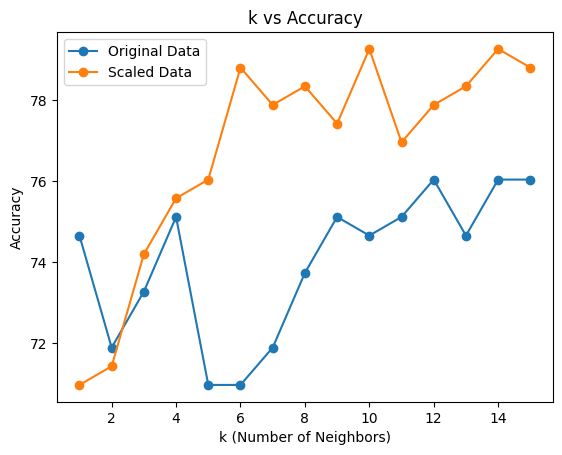

In [13]:
import matplotlib.pyplot as plt

plt.figure()
#Plotting K vs accuracy
plt.plot(k_values, acc_original_list, marker='o', label='Original Data')
plt.plot(k_values, acc_scaled_list, marker='o', label='Scaled Data')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.title("k vs Accuracy")
plt.legend()
plt.show()

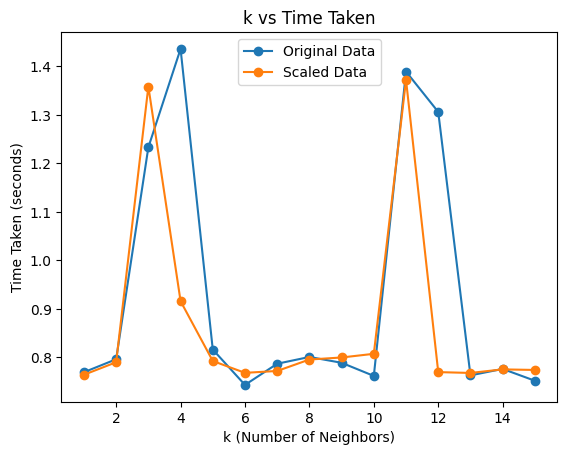

In [14]:
plt.figure()
#Plotting  K vs  Time taken
plt.plot(k_values, time_original_list, marker='o', label='Original Data')
plt.plot(k_values, time_scaled_list, marker='o', label='Scaled Data')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Time Taken (seconds)")
plt.title("k vs Time Taken")
plt.legend()
plt.show()

3. Analyze and Discuss:
• Discuss how the choice of k affects the accuracy and computational cost.
• Identify the optimal k based on your analysis.

## How scaling impacted accuracy

For very small values of k, the model is sensitive to noise and may overfit. As k increases,we can see that accuracy stabilizes, but very large k values may cause underfitting

## How Scaling impacted time taken